<a href="https://colab.research.google.com/github/UNSW-ZZSC9020/project/blob/main/src/GoogleColab.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Welcome to ZZSC9020

This Python notebook shows how to clone the course GitHub repository on Google Colab.

You can develop your data analysis on Google Colab without downloading the data to your computer.

In [25]:
# Clean up and start fresh
!rm -rf zzsc9020-teamc data

# Clone fresh
!git clone https://github.com/t-frank-unsw/zzsc9020-teamc.git

# Check what files actually exist in the repo
!ls -la zzsc9020-teamc/data/NSW/

# Make data folder
!mkdir -p data

# Try the concatenation again (let's see what the actual filenames are)
!cat zzsc9020-teamc/data/NSW/forecastdemand_nsw.csv.zip.part* > data/forecastdemand_nsw.csv.zip

# Unzip all files
!unzip data/forecastdemand_nsw.csv.zip -d data
!unzip zzsc9020-teamc/data/NSW/temperature_nsw.csv.zip -d data
!unzip zzsc9020-teamc/data/NSW/totaldemand_nsw.csv.zip -d data

# Clean up
!rm data/forecastdemand_nsw.csv.zip

# Final check
!ls -lh data/

Cloning into 'zzsc9020-teamc'...
remote: Enumerating objects: 145, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 145 (delta 24), reused 16 (delta 16), pack-reused 113 (from 4)
Receiving objects: 100% (145/145), 203.01 MiB | 29.69 MiB/s, done.
Resolving deltas: 100% (37/37), done.
Updating files: 100% (23/23), done.
total 118904
drwxr-xr-x 2 root root      4096 Sep 19 21:08 .
drwxr-xr-x 3 root root      4096 Sep 19 21:08 ..
-rw-r--r-- 1 root root 104857600 Sep 19 21:08 forecastdemand_nsw.csv.zip.partaa
-rw-r--r-- 1 root root  14669007 Sep 19 21:08 forecastdemand_nsw.csv.zip.partab
-rw-r--r-- 1 root root    920562 Sep 19 21:08 temperature_nsw.csv.zip
-rw-r--r-- 1 root root   1296200 Sep 19 21:08 totaldemand_nsw.csv.zip
Archive:  data/forecastdemand_nsw.csv.zip
  inflating: data/forecastdemand_nsw.csv  
Archive:  zzsc9020-teamc/data/NSW/temperature_nsw.csv.zip
  inflating: data/temperature_nsw.csv  
Archive:  zzsc9020-te

In [27]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

PATH_FORECAST = "data/forecastdemand_nsw.csv"
PATH_TEMP     = "data/temperature_nsw.csv"
PATH_ACTUAL   = "data/totaldemand_nsw.csv"

def dt_dayfirst(s):
    return pd.to_datetime(s, errors="coerce", dayfirst=True, infer_datetime_format=True)

def dt_us(s):
    s = s.astype(str).str.strip().str.replace(r"(\d{1,2})/(\d{1,2})/(\d{2})(?!\d)", r"\1/\2/20\3", regex=True)
    return pd.to_datetime(s, errors="coerce", dayfirst=False, infer_datetime_format=True)

# daily actual peak
a = (pd.read_csv(PATH_ACTUAL, usecols=["DATETIME","TOTALDEMAND","REGIONID"])
      .query("REGIONID=='NSW1'").drop(columns="REGIONID"))
a["DATETIME"] = dt_dayfirst(a["DATETIME"])
a["ACTUAL"] = pd.to_numeric(a["TOTALDEMAND"], errors="coerce")
a = a.dropna(subset=["DATETIME","ACTUAL"])
a["DATE"] = a["DATETIME"].dt.floor("D")
daily_actual = a.groupby("DATE", as_index=False)["ACTUAL"].max().rename(columns={"ACTUAL":"ACTUAL_PEAK"})

# daily max AND min temp
t = pd.read_csv(PATH_TEMP).rename(columns={"TemperatureTEMPERATURE":"TEMPERATURE"})
t["DATETIME"] = dt_dayfirst(t["DATETIME"])
t["TEMPERATURE"] = pd.to_numeric(t["TEMPERATURE"], errors="coerce")
t = t.dropna(subset=["DATETIME","TEMPERATURE"])
t["DATE"] = t["DATETIME"].dt.floor("D")
daily_temp = t.groupby("DATE", as_index=False)["TEMPERATURE"].agg({
    "TEMP_MAX": "max",
    "TEMP_MIN": "min"
})

# Forecast max from day before
f = (pd.read_csv(PATH_FORECAST, usecols=["DATETIME","FORECASTDEMAND","REGIONID","LASTCHANGED"])
      .query("REGIONID=='NSW1'").drop(columns="REGIONID"))
f["DATETIME"]    = dt_us(f["DATETIME"])
f["LASTCHANGED"] = dt_us(f["LASTCHANGED"])
f["FORECASTDEMAND"] = pd.to_numeric(f["FORECASTDEMAND"], errors="coerce")
f = f.dropna(subset=["DATETIME","LASTCHANGED","FORECASTDEMAND"])
f["DATE_TARGET"] = f["DATETIME"].dt.floor("D")
f["DATE_ISSUE"]  = f["LASTCHANGED"].dt.floor("D")
f_day_ahead = f.loc[f["DATE_ISSUE"].eq(f["DATE_TARGET"] - pd.Timedelta(days=1))]
daily_forecast = (f_day_ahead.groupby("DATE_TARGET", as_index=False)["FORECASTDEMAND"]
                  .max().rename(columns={"DATE_TARGET":"DATE","FORECASTDEMAND":"FORECAST_PEAK_24H"}))

# Merge
daily = (daily_actual.merge(daily_temp, on="DATE", how="left")
                     .merge(daily_forecast, on="DATE", how="left"))
daily["ERROR"] = daily["ACTUAL_PEAK"] - daily["FORECAST_PEAK_24H"]
daily["YEAR"]  = daily["DATE"].dt.year

# Add extreme temperature flags based on your criteria
daily["EXTREME_HOT"] = (daily["TEMP_MAX"] > 35).astype(int)   # Hot tail: max temp > 35°C
daily["EXTREME_COLD"] = (daily["TEMP_MIN"] < 5).astype(int)   # Cold tail: min temp < 5°C
daily["TEMP_EXTREME"] = ((daily["EXTREME_HOT"] == 1) | (daily["EXTREME_COLD"] == 1)).astype(int)

Max Temperature Analysis:


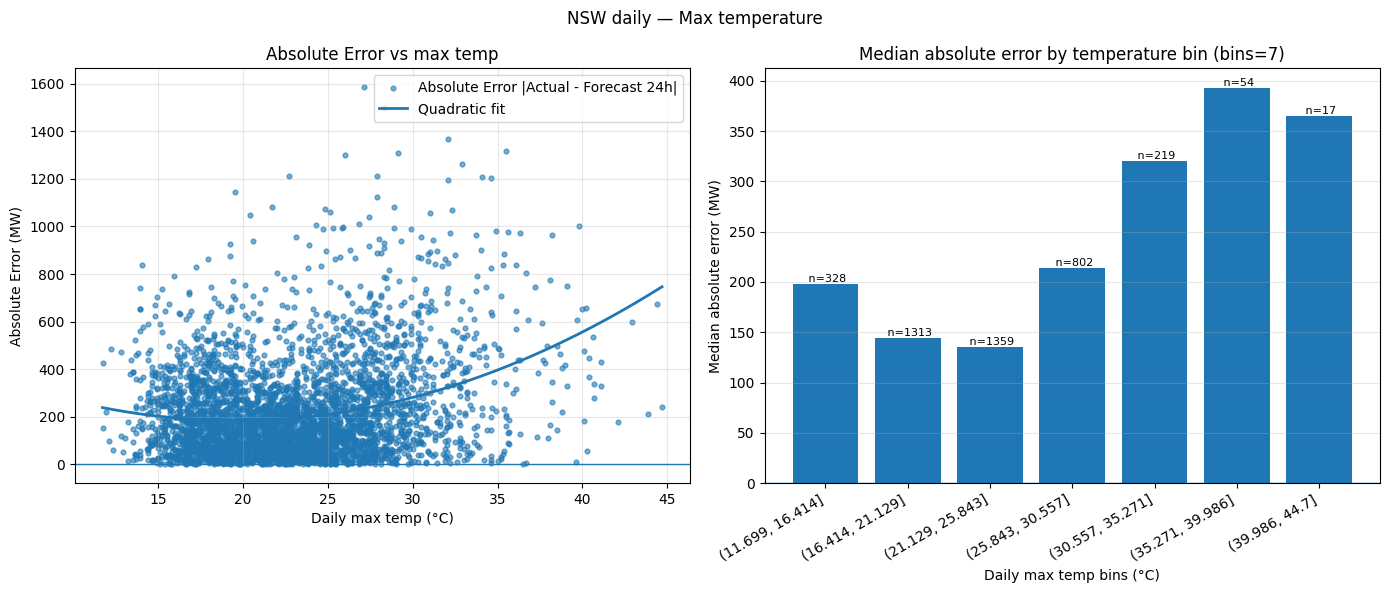


Min Temperature Analysis:


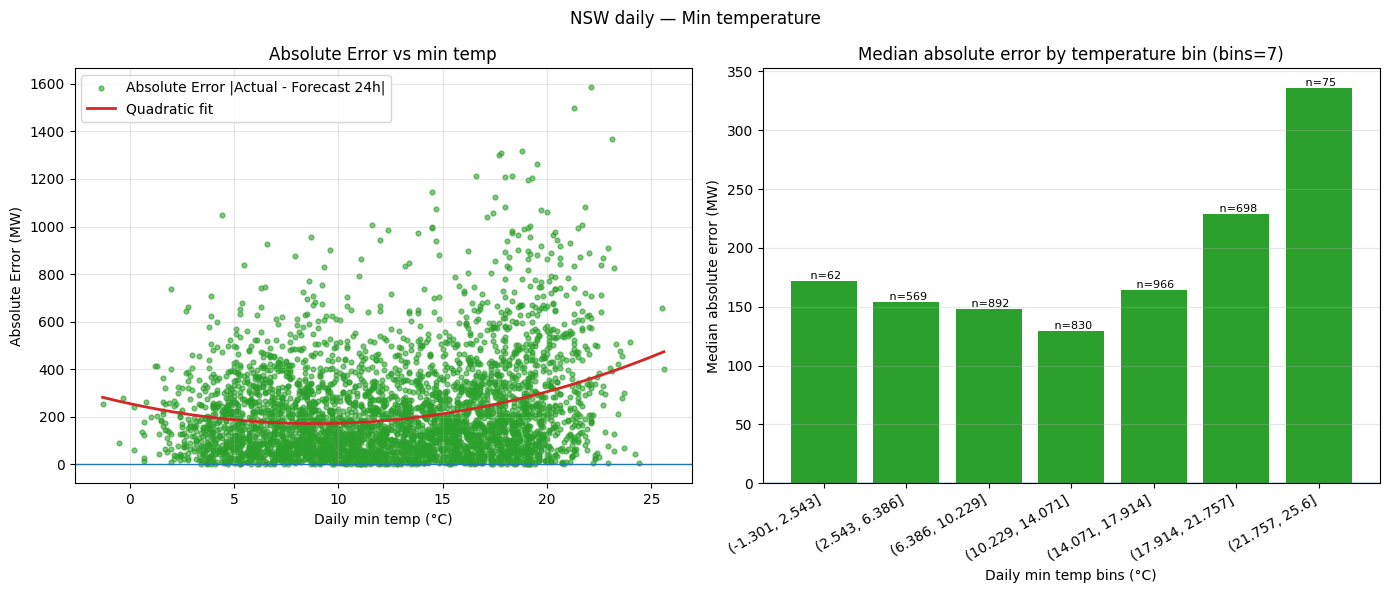

In [31]:
# Plot functions for both max and min temperature
def _quad_fit(x, y, n=200):
    x, y = np.asarray(x, float), np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3: return np.array([]), np.array([])
    xm, xs = x[m].mean(), (x[m].std() or 1.0)
    coef = np.polyfit((x[m]-xm)/xs, y[m], deg=2)
    xg = np.linspace(x[m].min(), x[m].max(), n)
    return xg, np.polyval(coef, (xg-xm)/xs)

def plot_error_views_max_temp(d, year=None, bins=7):
    d = d.loc[d["YEAR"].eq(year)] if year is not None else d
    d = d.dropna(subset=["TEMP_MAX","ERROR"]).copy()
    if d.empty: return
    x, e = d["TEMP_MAX"].to_numpy(), np.abs(d["ERROR"].to_numpy())
    xg, e_fit = _quad_fit(x, e)

    fig, axs = plt.subplots(1,2, figsize=(14,6))
    axs[0].axhline(0, linewidth=1)
    axs[0].scatter(x, e, alpha=0.6, s=12, label="Absolute Error |Actual - Forecast 24h|")
    if xg.size: axs[0].plot(xg, e_fit, linewidth=2, label="Quadratic fit")
    axs[0].set_xlabel("Daily max temp (°C)"); axs[0].set_ylabel("Absolute Error (MW)")
    axs[0].set_title("Absolute Error vs max temp"); axs[0].legend(); axs[0].grid(True, alpha=0.3)

    edges = np.linspace(d["TEMP_MAX"].min(), d["TEMP_MAX"].max(), bins+1)
    d = d.assign(TEMP_BIN=pd.cut(d["TEMP_MAX"], bins=edges, include_lowest=True),
                 ABS_ERROR=np.abs(d["ERROR"]))
    g = d.groupby("TEMP_BIN", observed=True).agg(mean_error=("ABS_ERROR","median"),
                                                 count=("ABS_ERROR","size")).reset_index()

    axs[1].bar(np.arange(len(g)), g["mean_error"])
    axs[1].axhline(0, linewidth=1)
    axs[1].set_xticks(np.arange(len(g))); axs[1].set_xticklabels(g["TEMP_BIN"].astype(str), rotation=30, ha="right")
    axs[1].set_xlabel("Daily max temp bins (°C)"); axs[1].set_ylabel("Median absolute error (MW)")
    axs[1].set_title(f"Median absolute error by temperature bin (bins={bins})")
    for i, (val, cnt) in enumerate(zip(g["mean_error"], g["count"])):
        axs[1].text(i, val, f" n={cnt}", ha="center", va="bottom", fontsize=8)
    axs[1].grid(True, axis="y", alpha=0.3)
    plt.suptitle(f"NSW daily — Max temperature{' ('+str(year)+')' if year else ''}")
    plt.tight_layout(); plt.show()

def plot_error_views_min_temp(d, year=None, bins=7):
    d = d.loc[d["YEAR"].eq(year)] if year is not None else d
    d = d.dropna(subset=["TEMP_MIN","ERROR"]).copy()
    if d.empty: return
    x, e = d["TEMP_MIN"].to_numpy(), np.abs(d["ERROR"].to_numpy())
    xg, e_fit = _quad_fit(x, e)

    fig, axs = plt.subplots(1,2, figsize=(14,6))
    axs[0].axhline(0, linewidth=1)
    axs[0].scatter(x, e, alpha=0.6, s=12, label="Absolute Error |Actual - Forecast 24h|", color="C2")
    if xg.size: axs[0].plot(xg, e_fit, linewidth=2, label="Quadratic fit", color="C3")
    axs[0].set_xlabel("Daily min temp (°C)"); axs[0].set_ylabel("Absolute Error (MW)")
    axs[0].set_title("Absolute Error vs min temp"); axs[0].legend(); axs[0].grid(True, alpha=0.3)

    edges = np.linspace(d["TEMP_MIN"].min(), d["TEMP_MIN"].max(), bins+1)
    d = d.assign(TEMP_BIN=pd.cut(d["TEMP_MIN"], bins=edges, include_lowest=True),
                 ABS_ERROR=np.abs(d["ERROR"]))
    g = d.groupby("TEMP_BIN", observed=True).agg(mean_error=("ABS_ERROR","median"),
                                                 count=("ABS_ERROR","size")).reset_index()

    axs[1].bar(np.arange(len(g)), g["mean_error"], color="C2")
    axs[1].axhline(0, linewidth=1)
    axs[1].set_xticks(np.arange(len(g))); axs[1].set_xticklabels(g["TEMP_BIN"].astype(str), rotation=30, ha="right")
    axs[1].set_xlabel("Daily min temp bins (°C)"); axs[1].set_ylabel("Median absolute error (MW)")
    axs[1].set_title(f"Median absolute error by temperature bin (bins={bins})")
    for i, (val, cnt) in enumerate(zip(g["mean_error"], g["count"])):
        axs[1].text(i, val, f" n={cnt}", ha="center", va="bottom", fontsize=8)
    axs[1].grid(True, axis="y", alpha=0.3)
    plt.suptitle(f"NSW daily — Min temperature{' ('+str(year)+')' if year else ''}")
    plt.tight_layout(); plt.show()

# Call both functions
print("Max Temperature Analysis:")
plot_error_views_max_temp(daily)
print("\nMin Temperature Analysis:")
plot_error_views_min_temp(daily)

Fitting 4 folds for each of 20 candidates, totalling 80 fits
Best params: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None}
Forecast (24h) on test: {'MAE': 202.20691931540335, 'RMSE': 279.9894423887162, 'MAPE_pct': np.float64(2.130460142646821), 'R2': np.float64(0.949495176654991)}
RandomForest on test: {'MAE': 195.87556674816616, 'RMSE': 269.250362202979, 'MAPE_pct': np.float64(2.063746830691602), 'R2': np.float64(0.9532951332351616)}

MAE improvement: 6.3 MW (3.1%)
RMSE improvement: 10.7 MW (3.8%)
R² improvement: 0.004 (0.4%)
Max Temperature Analysis:


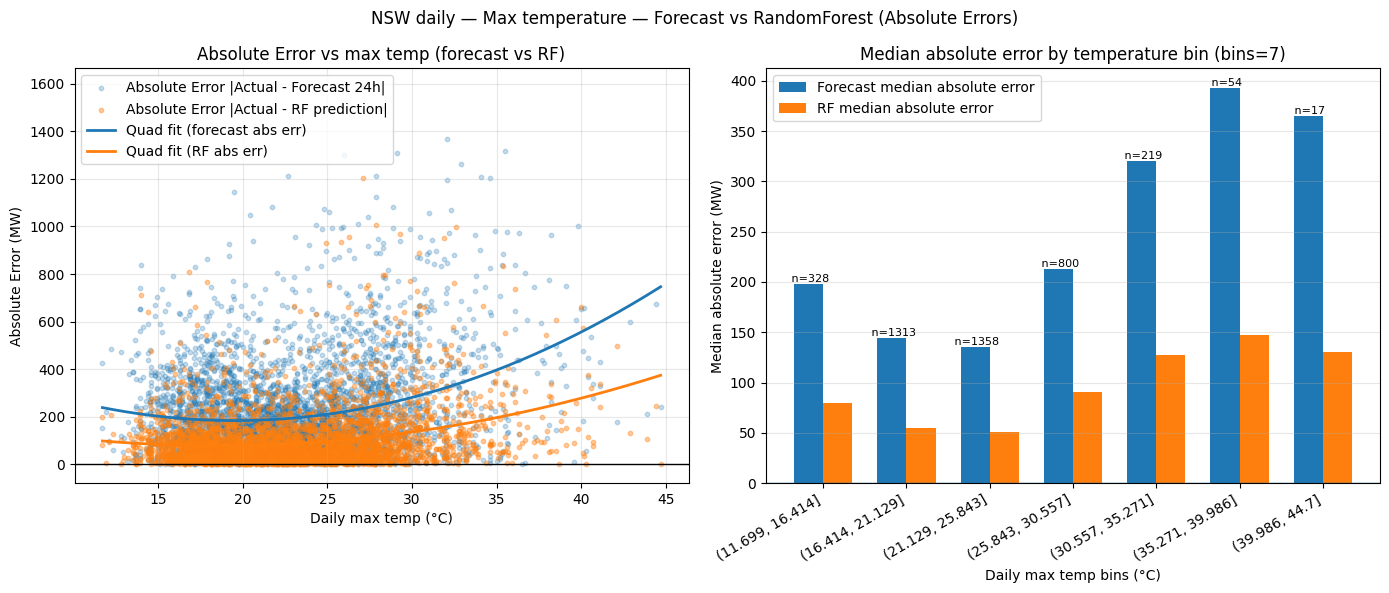


Min Temperature Analysis:


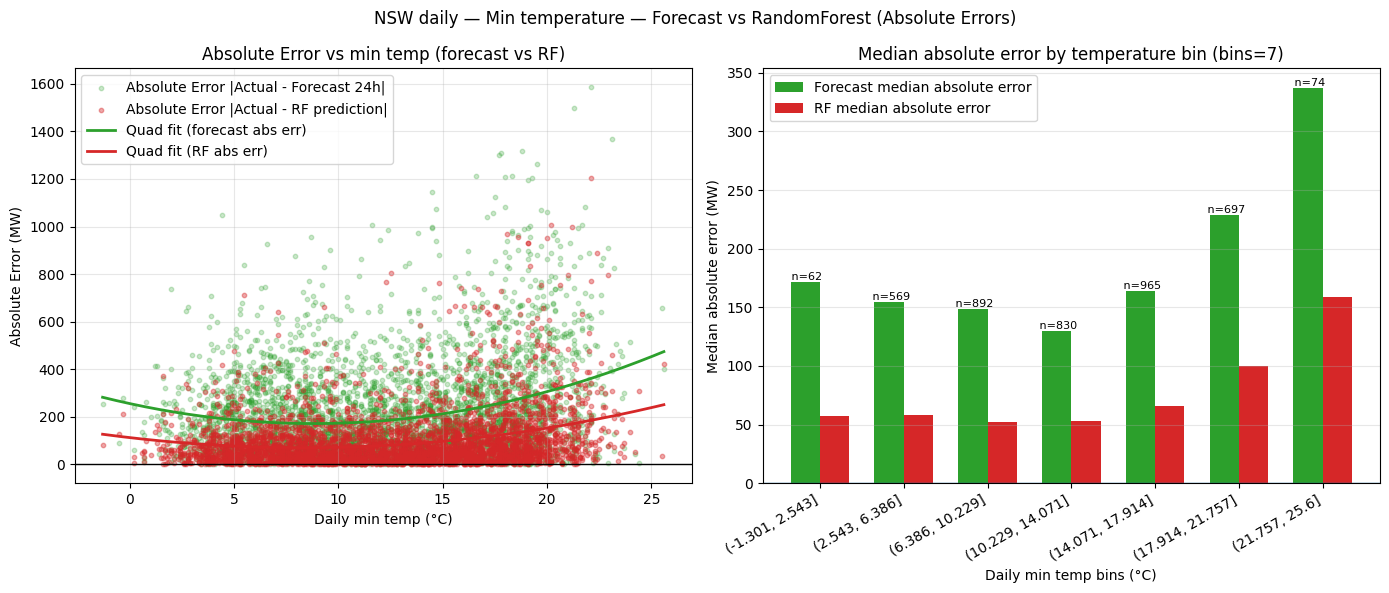

Feature importances (top 15):
FORECAST_PEAK_24H    0.660313
FORECAST_lag1        0.135364
TEMP_MAX             0.047897
FORECAST_roll3       0.046674
CDD_24               0.026099
TEMP_EXTREME         0.015615
DOY_cos              0.010201
EXTREME_HOT          0.009038
TEMP_MAX_roll3       0.005774
TEMP_MIN             0.005381
TEMP_MAX_lag1        0.005236
DOY_sin              0.004825
TEMP_RANGE           0.003654
TEMP_MIN_lag1        0.003441
TEMP_MAX_lag3        0.003247
dtype: float64

Improvement by temperature extremes:
Hot days (max >35°C): {'n': 76, 'forecast_MAE': 412.73315789473685, 'forecast_R2': np.float64(0.8472073067467959), 'rf_MAE': 201.30323026315713, 'rf_R2': np.float64(0.955419175683762), 'MAE_reduction': 211.42992763157972, 'R2_improvement': np.float64(0.1082118689369661)}
Cold days (min <5°C): {'n': 355, 'forecast_MAE': 174.8478028169015, 'forecast_R2': np.float64(0.9246822615024998), 'rf_MAE': 73.97237183098419, 'rf_R2': np.float64(0.9842681595899401), 'MAE_reduc

In [32]:
# Random forest model to predict daily peak demand from TEMP_MAX/MIN + other features
# Assumes `daily` DataFrame already exists (columns: DATE, ACTUAL_PEAK, TEMP_MAX, TEMP_MIN, FORECAST_PEAK_24H, YEAR, ERROR, EXTREME_HOT, EXTREME_COLD, TEMP_EXTREME)

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import math
import warnings
warnings.filterwarnings("ignore")
RSEED = 42

#Prepare features (operate on a copy)
d = daily.copy().sort_values("DATE").reset_index(drop=True)
# Drop rows with missing target, TEMP_MAX, or TEMP_MIN
d = d.dropna(subset=["ACTUAL_PEAK","TEMP_MAX","TEMP_MIN"]).reset_index(drop=True)

# Feature engineering
d["FORECAST_PEAK_24H"] = d["FORECAST_PEAK_24H"].fillna(method="ffill").fillna(d["ACTUAL_PEAK"].median())
# Calendar features
d["DOY"] = d["DATE"].dt.dayofyear
# cyclical encoding for day-of-year
d["DOY_sin"] = np.sin(2*np.pi * d["DOY"]/365.25)
d["DOY_cos"] = np.cos(2*np.pi * d["DOY"]/365.25)
d["YEAR"] = d["DATE"].dt.year

# Temperature range
d["TEMP_RANGE"] = d["TEMP_MAX"] - d["TEMP_MIN"]

# Lags & rolling stats on TEMP_MAX, TEMP_MIN and forecasts
for lag in [1,2,3]:
    d[f"TEMP_MAX_lag{lag}"] = d["TEMP_MAX"].shift(lag)
    d[f"TEMP_MIN_lag{lag}"] = d["TEMP_MIN"].shift(lag)
    d[f"FORECAST_lag{lag}"] = d["FORECAST_PEAK_24H"].shift(lag)

# Rolling mean of previous 3 days
d["TEMP_MAX_roll3"] = d["TEMP_MAX"].shift(1).rolling(3, min_periods=1).mean()
d["TEMP_MIN_roll3"] = d["TEMP_MIN"].shift(1).rolling(3, min_periods=1).mean()
d["FORECAST_roll3"]  = d["FORECAST_PEAK_24H"].shift(1).rolling(3, min_periods=1).mean()

# Degree days (simple): baseline 18°C for heating, 24°C for cooling
d["CDD_24"] = np.clip(d["TEMP_MAX"] - 24.0, 0, None)   # cooling degree days
d["HDD_18"] = np.clip(18.0 - d["TEMP_MIN"], 0, None)   # heating degree days (using min temp)

# Target
d = d.dropna().reset_index(drop=True)  # drop rows with any NA from lags
y = d["ACTUAL_PEAK"].values

# Candidate predictors (now includes min temp features)
features = [
    "TEMP_MAX","TEMP_MIN","TEMP_RANGE",
    "TEMP_MAX_roll3","TEMP_MIN_roll3",
    "TEMP_MAX_lag1","TEMP_MAX_lag2","TEMP_MAX_lag3",
    "TEMP_MIN_lag1","TEMP_MIN_lag2","TEMP_MIN_lag3",
    "FORECAST_PEAK_24H","FORECAST_roll3","FORECAST_lag1",
    "DOY_sin","DOY_cos","YEAR",
    "CDD_24","HDD_18","TEMP_EXTREME","EXTREME_HOT","EXTREME_COLD"
]
X = d[features].astype(float)

#Train/test split: time-wise (last 20% as test)
n = len(d)
test_size = int(math.ceil(n * 0.20))
train_idx = np.arange(0, n - test_size)
test_idx  = np.arange(n - test_size, n)

X_train, y_train = X.iloc[train_idx], y[train_idx]
X_test,  y_test  = X.iloc[test_idx],  y[test_idx]

#Sample weights to focus the model on extremes: upweight extreme temps
alpha = 3.0
temp_med = X_train["TEMP_MAX"].median()
temp_iqr = (X_train["TEMP_MAX"].quantile(0.75) - X_train["TEMP_MAX"].quantile(0.25)) or 1.0
# distance measure
dist = np.abs(X_train["TEMP_MAX"] - temp_med) / temp_iqr
sample_weight = 1.0 + alpha * (dist / (dist.max() if dist.max()>0 else 1.0))
# also ensure extremes flagged strongly
sample_weight = sample_weight * (1.0 + 2.0 * X_train["TEMP_EXTREME"])

#Random Forest with randomized search
rf = RandomForestRegressor(random_state=RSEED, n_jobs=-1)
param_dist = {
    "n_estimators": [200, 400, 800],
    "max_depth": [6, 10, 16, None],
    "min_samples_leaf": [1,2,4,8],
    "max_features": ["auto","sqrt",0.5]
}
tscv = TimeSeriesSplit(n_splits=4)
rs = RandomizedSearchCV(
    rf, param_distributions=param_dist, n_iter=20,
    cv=tscv, scoring="neg_mean_absolute_error", random_state=RSEED, n_jobs=-1, verbose=1
)

rs.fit(X_train, y_train, sample_weight=sample_weight.values)
best = rs.best_estimator_
print("Best params:", rs.best_params_)

# Predict
pred_train = best.predict(X_train)
pred_test  = best.predict(X_test)
pred_all   = best.predict(X)

# Metrics
def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    # R-squared
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    return {"MAE":mae, "RMSE":rmse, "MAPE_pct":mape, "R2":r2}

metrics_forecast_test = metrics(y_test, X_test["FORECAST_PEAK_24H"].values)
metrics_rf_test = metrics(y_test, pred_test)
print("Forecast (24h) on test:", metrics_forecast_test)
print("RandomForest on test:", metrics_rf_test)

# Calculate improvement
mae_improvement = metrics_forecast_test["MAE"] - metrics_rf_test["MAE"]
rmse_improvement = metrics_forecast_test["RMSE"] - metrics_rf_test["RMSE"]
r2_improvement = metrics_rf_test["R2"] - metrics_forecast_test["R2"]
print(f"\nMAE improvement: {mae_improvement:.1f} MW ({mae_improvement/metrics_forecast_test['MAE']*100:.1f}%)")
print(f"RMSE improvement: {rmse_improvement:.1f} MW ({rmse_improvement/metrics_forecast_test['RMSE']*100:.1f}%)")
print(f"R² improvement: {r2_improvement:.3f} ({r2_improvement/metrics_forecast_test['R2']*100:.1f}%)")

# Attach predictions and residuals to d
d["PRED_RF"] = pred_all
d["RESID_RF"] = d["ACTUAL_PEAK"] - d["PRED_RF"]
d["RESID_FORECAST"] = d["ACTUAL_PEAK"] - d["FORECAST_PEAK_24H"]

# Plot comparison functions for both max and min temperature
def plot_compare_rf_max_temp(dframe, year=None, bins=7):
    dd = dframe.loc[dframe["YEAR"].eq(year)] if year is not None else dframe
    dd = dd.dropna(subset=["TEMP_MAX","RESID_FORECAST","RESID_RF"]).copy()
    if dd.empty:
        print("No data")
        return

    x = dd["TEMP_MAX"].to_numpy()
    e_fc = np.abs(dd["RESID_FORECAST"].to_numpy())
    e_rf = np.abs(dd["RESID_RF"].to_numpy())

    def quad_fit(x, y, n=200):
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 3: return np.array([]), np.array([])
        xm, xs = x[m].mean(), (x[m].std() or 1.0)
        coef = np.polyfit((x[m]-xm)/xs, y[m], deg=2)
        xg = np.linspace(x[m].min(), x[m].max(), n)
        return xg, np.polyval(coef, (xg-xm)/xs)

    xg_fc, e_fit_fc = quad_fit(x, e_fc)
    xg_rf, e_fit_rf = quad_fit(x, e_rf)

    fig, axs = plt.subplots(1,2, figsize=(14,6))

    axs[0].axhline(0, linewidth=1, color="k")
    axs[0].scatter(x, e_fc, alpha=0.25, s=10, label="Absolute Error |Actual - Forecast 24h|", color="C0")
    axs[0].scatter(x, e_rf, alpha=0.4, s=10, label="Absolute Error |Actual - RF prediction|", color="C1")
    if xg_fc.size: axs[0].plot(xg_fc, e_fit_fc, linewidth=2, color="C0", label="Quad fit (forecast abs err)")
    if xg_rf.size: axs[0].plot(xg_rf, e_fit_rf, linewidth=2, color="C1", label="Quad fit (RF abs err)")
    axs[0].set_xlabel("Daily max temp (°C)"); axs[0].set_ylabel("Absolute Error (MW)")
    axs[0].set_title("Absolute Error vs max temp (forecast vs RF)")
    axs[0].legend(); axs[0].grid(True, alpha=0.3)

    edges = np.linspace(dd["TEMP_MAX"].min(), dd["TEMP_MAX"].max(), bins+1)
    dd = dd.assign(TEMP_BIN=pd.cut(dd["TEMP_MAX"], bins=edges, include_lowest=True),
                   ABS_RESID_FORECAST=np.abs(dd["RESID_FORECAST"]),
                   ABS_RESID_RF=np.abs(dd["RESID_RF"]))
    g_fc = dd.groupby("TEMP_BIN", observed=True).agg(med_err_fc=("ABS_RESID_FORECAST","median"),
                                                     count=("ABS_RESID_FORECAST","size")).reset_index()
    g_rf = dd.groupby("TEMP_BIN", observed=True).agg(med_err_rf=("ABS_RESID_RF","median")).reset_index()

    g = g_fc.merge(g_rf, on="TEMP_BIN")
    idx = np.arange(len(g))
    width = 0.35
    axs[1].bar(idx - width/2, g["med_err_fc"], width=width, label="Forecast median absolute error")
    axs[1].bar(idx + width/2, g["med_err_rf"], width=width, label="RF median absolute error")
    axs[1].axhline(0, linewidth=1)
    axs[1].set_xticks(idx); axs[1].set_xticklabels(g["TEMP_BIN"].astype(str), rotation=30, ha="right")
    axs[1].set_xlabel("Daily max temp bins (°C)"); axs[1].set_ylabel("Median absolute error (MW)")
    axs[1].set_title(f"Median absolute error by temperature bin (bins={bins})")
    for i, (fcv, rfv, cnt) in enumerate(zip(g["med_err_fc"], g["med_err_rf"], g["count"])):
        axs[1].text(i - width/2, fcv, f" n={cnt}", ha="center", va="bottom", fontsize=8)
    axs[1].legend(); axs[1].grid(True, axis="y", alpha=0.3)

    plt.suptitle(f"NSW daily — Max temperature{' ('+str(year)+')' if year else ''} — Forecast vs RandomForest (Absolute Errors)")
    plt.tight_layout(); plt.show()

def plot_compare_rf_min_temp(dframe, year=None, bins=7):
    dd = dframe.loc[dframe["YEAR"].eq(year)] if year is not None else dframe
    dd = dd.dropna(subset=["TEMP_MIN","RESID_FORECAST","RESID_RF"]).copy()
    if dd.empty:
        print("No data")
        return

    x = dd["TEMP_MIN"].to_numpy()
    e_fc = np.abs(dd["RESID_FORECAST"].to_numpy())
    e_rf = np.abs(dd["RESID_RF"].to_numpy())

    def quad_fit(x, y, n=200):
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 3: return np.array([]), np.array([])
        xm, xs = x[m].mean(), (x[m].std() or 1.0)
        coef = np.polyfit((x[m]-xm)/xs, y[m], deg=2)
        xg = np.linspace(x[m].min(), x[m].max(), n)
        return xg, np.polyval(coef, (xg-xm)/xs)

    xg_fc, e_fit_fc = quad_fit(x, e_fc)
    xg_rf, e_fit_rf = quad_fit(x, e_rf)

    fig, axs = plt.subplots(1,2, figsize=(14,6))

    axs[0].axhline(0, linewidth=1, color="k")
    axs[0].scatter(x, e_fc, alpha=0.25, s=10, label="Absolute Error |Actual - Forecast 24h|", color="C2")
    axs[0].scatter(x, e_rf, alpha=0.4, s=10, label="Absolute Error |Actual - RF prediction|", color="C3")
    if xg_fc.size: axs[0].plot(xg_fc, e_fit_fc, linewidth=2, color="C2", label="Quad fit (forecast abs err)")
    if xg_rf.size: axs[0].plot(xg_rf, e_fit_rf, linewidth=2, color="C3", label="Quad fit (RF abs err)")
    axs[0].set_xlabel("Daily min temp (°C)"); axs[0].set_ylabel("Absolute Error (MW)")
    axs[0].set_title("Absolute Error vs min temp (forecast vs RF)")
    axs[0].legend(); axs[0].grid(True, alpha=0.3)

    edges = np.linspace(dd["TEMP_MIN"].min(), dd["TEMP_MIN"].max(), bins+1)
    dd = dd.assign(TEMP_BIN=pd.cut(dd["TEMP_MIN"], bins=edges, include_lowest=True),
                   ABS_RESID_FORECAST=np.abs(dd["RESID_FORECAST"]),
                   ABS_RESID_RF=np.abs(dd["RESID_RF"]))
    g_fc = dd.groupby("TEMP_BIN", observed=True).agg(med_err_fc=("ABS_RESID_FORECAST","median"),
                                                     count=("ABS_RESID_FORECAST","size")).reset_index()
    g_rf = dd.groupby("TEMP_BIN", observed=True).agg(med_err_rf=("ABS_RESID_RF","median")).reset_index()

    g = g_fc.merge(g_rf, on="TEMP_BIN")
    idx = np.arange(len(g))
    width = 0.35
    axs[1].bar(idx - width/2, g["med_err_fc"], width=width, label="Forecast median absolute error", color="C2")
    axs[1].bar(idx + width/2, g["med_err_rf"], width=width, label="RF median absolute error", color="C3")
    axs[1].axhline(0, linewidth=1)
    axs[1].set_xticks(idx); axs[1].set_xticklabels(g["TEMP_BIN"].astype(str), rotation=30, ha="right")
    axs[1].set_xlabel("Daily min temp bins (°C)"); axs[1].set_ylabel("Median absolute error (MW)")
    axs[1].set_title(f"Median absolute error by temperature bin (bins={bins})")
    for i, (fcv, rfv, cnt) in enumerate(zip(g["med_err_fc"], g["med_err_rf"], g["count"])):
        axs[1].text(i - width/2, fcv, f" n={cnt}", ha="center", va="bottom", fontsize=8)
    axs[1].legend(); axs[1].grid(True, axis="y", alpha=0.3)

    plt.suptitle(f"NSW daily — Min temperature{' ('+str(year)+')' if year else ''} — Forecast vs RandomForest (Absolute Errors)")
    plt.tight_layout(); plt.show()

# Generate both sets of plots
print("Max Temperature Analysis:")
plot_compare_rf_max_temp(d)
print("\nMin Temperature Analysis:")
plot_compare_rf_min_temp(d)

# Feature importances
fi = pd.Series(best.feature_importances_, index=features).sort_values(ascending=False)
print("Feature importances (top 15):")
print(fi.head(15))

# Quantifying improvement by temperature extremes (your definitions)
def improvement_by_temp_extremes(dframe):
    hot = dframe.loc[dframe["EXTREME_HOT"] == 1]    # Max temp > 35°C
    cold = dframe.loc[dframe["EXTREME_COLD"] == 1]  # Min temp < 5°C
    normal = dframe.loc[(dframe["EXTREME_HOT"] == 0) & (dframe["EXTREME_COLD"] == 0)]

    def comp(sub, label):
        if len(sub)==0: return {}
        fc = metrics(sub["ACTUAL_PEAK"].values, sub["FORECAST_PEAK_24H"].values)
        rf = metrics(sub["ACTUAL_PEAK"].values, sub["PRED_RF"].values)
        return {label: {"n":len(sub), "forecast_MAE":fc["MAE"], "forecast_R2":fc["R2"],
                "rf_MAE":rf["MAE"], "rf_R2":rf["R2"],
                "MAE_reduction": fc["MAE"]-rf["MAE"], "R2_improvement": rf["R2"]-fc["R2"]}}

    print("\nImprovement by temperature extremes:")
    result = {}
    result.update(comp(hot, "Hot days (max >35°C)"))
    result.update(comp(cold, "Cold days (min <5°C)"))
    result.update(comp(normal, "Normal days"))

    for key, values in result.items():
        print(f"{key}: {values}")

improvement_by_temp_extremes(d)